# Practica 1: Indice de marginacion municipal (version vdmc)

Este notebook integra lo mejor de los enfoques usados en los notebooks del equipo:

- Seleccion de variables por correlacion y variabilidad (estilo `g33_m3p1_eq5_notebook_RGM.ipynb`).
- Seleccion de variables por definicion de marginacion (estilo `g33_m3p1_eq5_notebook_DMC.ipynb`).
- PCA a 2 dimensiones y construccion de un indice (inspirado en `src/M3_2_1_Analisis_Componentes_Principales.ipynb`).

Contexto: la practica de metodos de reduccion (ver `src/M3P1_Metodos_Reduccion.pdf`) sugiere un flujo EDA -> seleccion de variables -> reduccion de dimensionalidad -> indice interpretable.


## 0. Configuracion inicial


In [1]:
import zipfile
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 250)


## 1. Carga de datos


In [4]:
zip_path = 'data/M3P1_Metodos_Reduccion.zip'

with zipfile.ZipFile(zip_path) as z:
    censo = pd.read_csv(
        z.open('iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv'),
        low_memory=False
    )
    dic_raw = pd.read_csv(
        z.open('iter_00_cpv2020/diccionario_datos/diccionario_datos_iter_00CSV20.csv'),
        header=None,
        low_memory=False
    )
    tam_loc = pd.read_csv(z.open('iter_00_cpv2020/catalogos/tam_loc.csv.csv'))

# Convertimos columnas numericas y preservamos nombres geograficos
geo_cols = ['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC']

for col in censo.columns:
    if col not in geo_cols:
        censo[col] = pd.to_numeric(censo[col], errors='coerce')

censo.head()


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,P_15YMAS_F,P_15YMAS_M,P_18YMAS,P_18YMAS_F,P_18YMAS_M,P_3A5,P_3A5_F,P_3A5_M,P_6A11,P_6A11_F,P_6A11_M,P_8A14,P_8A14_F,P_8A14_M,P_12A14,P_12A14_F,P_12A14_M,P_15A17,P_15A17_F,P_15A17_M,P_18A24,P_18A24_F,P_18A24_M,P_15A49_F,P_60YMAS,P_60YMAS_F,P_60YMAS_M,REL_H_M,POB0_14,POB15_64,POB65_MAS,P_0A4,P_0A4_F,P_0A4_M,P_5A9,P_5A9_F,P_5A9_M,P_10A14,P_10A14_F,P_10A14_M,P_15A19,P_15A19_F,P_15A19_M,P_20A24,P_20A24_F,P_20A24_M,P_25A29,P_25A29_F,P_25A29_M,P_30A34,P_30A34_F,P_30A34_M,P_35A39,P_35A39_F,P_35A39_M,P_40A44,P_40A44_F,P_40A44_M,P_45A49,P_45A49_F,P_45A49_M,P_50A54,P_50A54_F,P_50A54_M,P_55A59,P_55A59_F,P_55A59_M,P_60A64,P_60A64_F,P_60A64_M,P_65A69,P_65A69_F,P_65A69_M,P_70A74,P_70A74_F,P_70A74_M,P_75A79,P_75A79_F,P_75A79_M,P_80A84,P_80A84_F,P_80A84_M,P_85YMAS,P_85YMAS_F,P_85YMAS_M,PROM_HNV,PNACENT,PNACENT_F,PNACENT_M,PNACOE,PNACOE_F,PNACOE_M,PRES2015,PRES2015_F,PRES2015_M,PRESOE15,PRESOE15_F,PRESOE15_M,P3YM_HLI,P3YM_HLI_F,...,P12A14NOA,P12A14NOAF,P12A14NOAM,P15A17A,P15A17A_F,P15A17A_M,P18A24A,P18A24A_F,P18A24A_M,P8A14AN,P8A14AN_F,P8A14AN_M,P15YM_AN,P15YM_AN_F,P15YM_AN_M,P15YM_SE,P15YM_SE_F,P15YM_SE_M,P15PRI_IN,P15PRI_INF,P15PRI_INM,P15PRI_CO,P15PRI_COF,P15PRI_COM,P15SEC_IN,P15SEC_INF,P15SEC_INM,P15SEC_CO,P15SEC_COF,P15SEC_COM,P18YM_PB,P18YM_PB_F,P18YM_PB_M,GRAPROES,GRAPROES_F,GRAPROES_M,PEA,PEA_F,PEA_M,PE_INAC,PE_INAC_F,PE_INAC_M,POCUPADA,POCUPADA_F,POCUPADA_M,PDESOCUP,PDESOCUP_F,PDESOCUP_M,PSINDER,PDER_SS,PDER_IMSS,PDER_ISTE,PDER_ISTEE,PAFIL_PDOM,PDER_SEGP,PDER_IMSSB,PAFIL_IPRIV,PAFIL_OTRAI,P12YM_SOLT,P12YM_CASA,P12YM_SEPA,PCATOLICA,PRO_CRIEVA,POTRAS_REL,PSIN_RELIG,TOTHOG,HOGJEF_F,HOGJEF_M,POBHOG,PHOGJEF_F,PHOGJEF_M,VIVTOT,TVIVHAB,TVIVPAR,VIVPAR_HAB,VIVPARH_CV,TVIVPARHAB,VIVPAR_DES,VIVPAR_UT,OCUPVIVPAR,PROM_OCUP,PRO_OCUP_C,VPH_PISODT,VPH_PISOTI,VPH_1DOR,VPH_2YMASD,VPH_1CUART,VPH_2CUART,VPH_3YMASC,VPH_C_ELEC,VPH_S_ELEC,VPH_AGUADV,VPH_AEASP,VPH_AGUAFV,VPH_TINACO,VPH_CISTER,VPH_EXCSA,VPH_LETR,VPH_DRENAJ,VPH_NODREN,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,64540634.0,61473390.0,5764054.0,2848875.0,2915179.0,119976584.0,61554567.0,58422017.0,115693273.0,59433559.0,56259714.0,100528155.0,51962264.0,48565891.0,93985354.0,48732991.0,45252363.0,87492680.0,45530857.0,41961823.0,6462212.0,3193548.0,3268664.0,12986217.0,6398755.0,6587462.0,15287375.0,7531118.0,7756257.0,6542801.0,3229273.0,3313528.0,6492674.0,3202134.0,3290540.0,14736111.0,7398617.0,7337494.0,33885546.0,15142976.0,8139094.0,7003882.0,95.25,31755284.0,83663440.0,10321914.0,10047365.0,4969883.0,5077482.0,10764379.0,5311288.0,5453091.0,10943540.0,5389280.0,5554260.0,10806690.0,5344540.0,5462150.0,10422095.0,5256211.0,5165884.0,9993001.0,5131597.0,4861404.0,9420827.0,4893101.0,4527726.0,9020276.0,4688746.0,4331530.0,8503586.0,4441282.0,4062304.0,7942413.0,4130069.0,3812344.0,7037532.0,3705369.0,3332163.0,5695958.0,3002982.0,2692976.0,4821062.0,2563200.0,2257862.0,3645077.0,1938227.0,1706850.0,2647340.0,1413848.0,1233492.0,1814582.0,966684.0,847898.0,1175364.0,651552.0,523812.0,1039551.0,605583.0,433968.0,2.09,102724322.0,52519974.0,50204348.0,21611963.0,11222300.0,10389663.0,111075594.0,57288776.0,53786818.0,3807844.0,1889986.0,1917858.0,7364645.0,3783447.0,...,618233.0,283195.0,335038.0,4726359.0,2390407.0,2335952.0,4894125.0,2482980.0,2411145.0,412725.0,178152.0,234573.0,4456431.0,2677192.0,1779239.0,4841952.0,2791237.0,2050715.0,7731820.0,4042527.0,3689293.0,12325433.0,6515268.0,5810165.0,2913915.0,1297269.0,1616646.0,22833912.0,11857736.0,10976176.0,39977750.0,20408275.0,19569475.0,9.74,9.64,9.84,62281634.0,

## 2. Filtrado por municipio y mejor version

La base contiene informacion a nivel localidad. Para trabajar marginacion municipal:

- Nos quedamos con registros municipales (`LOC == 0` o `NOM_LOC` con texto de total).
- Si existe mas de un registro por municipio, elegimos la version con mayor completitud.


In [5]:
mun_candidates = censo.copy()

mask_loc0 = mun_candidates['LOC'].astype(str).str.fullmatch(r'0+', na=False)
mask_total = mun_candidates['NOM_LOC'].astype(str).str.contains('Total del municipio', case=False, na=False)

mun_candidates = mun_candidates[mask_loc0 | mask_total].copy()

id_cols = ['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC']
value_cols = [c for c in mun_candidates.columns if c not in id_cols]

mun_candidates['completitud_fila'] = mun_candidates[value_cols].notna().mean(axis=1)

mun = (
    mun_candidates
    .sort_values(['ENTIDAD', 'MUN', 'completitud_fila', 'LOC'], ascending=[True, True, False, True])
    .drop_duplicates(['ENTIDAD', 'MUN'])
    .drop(columns=['completitud_fila'])
    .reset_index(drop=True)
)

print(f'Filas municipales: {mun.shape[0]:,}  |  Columnas: {mun.shape[1]:,}')
print(f'Entidades: {mun.NOM_ENT.nunique():,}  |  Municipios unicos: {mun[["ENTIDAD","MUN"]].drop_duplicates().shape[0]:,}')


Filas municipales: 2,502  |  Columnas: 286
Entidades: 33  |  Municipios unicos: 2,502


## 3. EDA para comprender la estructura de la data

Mejoras incluidas:

- Distribucion de poblacion y viviendas.
- Perfil de tipos de columnas.
- Analisis de faltantes por variable y por fila.
- Estratificacion por tamano de localidad (TAMLOC).


In [6]:
mun.head()


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,P_15YMAS_F,P_15YMAS_M,P_18YMAS,P_18YMAS_F,P_18YMAS_M,P_3A5,P_3A5_F,P_3A5_M,P_6A11,P_6A11_F,P_6A11_M,P_8A14,P_8A14_F,P_8A14_M,P_12A14,P_12A14_F,P_12A14_M,P_15A17,P_15A17_F,P_15A17_M,P_18A24,P_18A24_F,P_18A24_M,P_15A49_F,P_60YMAS,P_60YMAS_F,P_60YMAS_M,REL_H_M,POB0_14,POB15_64,POB65_MAS,P_0A4,P_0A4_F,P_0A4_M,P_5A9,P_5A9_F,P_5A9_M,P_10A14,P_10A14_F,P_10A14_M,P_15A19,P_15A19_F,P_15A19_M,P_20A24,P_20A24_F,P_20A24_M,P_25A29,P_25A29_F,P_25A29_M,P_30A34,P_30A34_F,P_30A34_M,P_35A39,P_35A39_F,P_35A39_M,P_40A44,P_40A44_F,P_40A44_M,P_45A49,P_45A49_F,P_45A49_M,P_50A54,P_50A54_F,P_50A54_M,P_55A59,P_55A59_F,P_55A59_M,P_60A64,P_60A64_F,P_60A64_M,P_65A69,P_65A69_F,P_65A69_M,P_70A74,P_70A74_F,P_70A74_M,P_75A79,P_75A79_F,P_75A79_M,P_80A84,P_80A84_F,P_80A84_M,P_85YMAS,P_85YMAS_F,P_85YMAS_M,PROM_HNV,PNACENT,PNACENT_F,PNACENT_M,PNACOE,PNACOE_F,PNACOE_M,PRES2015,PRES2015_F,PRES2015_M,PRESOE15,PRESOE15_F,PRESOE15_M,P3YM_HLI,P3YM_HLI_F,...,P12A14NOA,P12A14NOAF,P12A14NOAM,P15A17A,P15A17A_F,P15A17A_M,P18A24A,P18A24A_F,P18A24A_M,P8A14AN,P8A14AN_F,P8A14AN_M,P15YM_AN,P15YM_AN_F,P15YM_AN_M,P15YM_SE,P15YM_SE_F,P15YM_SE_M,P15PRI_IN,P15PRI_INF,P15PRI_INM,P15PRI_CO,P15PRI_COF,P15PRI_COM,P15SEC_IN,P15SEC_INF,P15SEC_INM,P15SEC_CO,P15SEC_COF,P15SEC_COM,P18YM_PB,P18YM_PB_F,P18YM_PB_M,GRAPROES,GRAPROES_F,GRAPROES_M,PEA,PEA_F,PEA_M,PE_INAC,PE_INAC_F,PE_INAC_M,POCUPADA,POCUPADA_F,POCUPADA_M,PDESOCUP,PDESOCUP_F,PDESOCUP_M,PSINDER,PDER_SS,PDER_IMSS,PDER_ISTE,PDER_ISTEE,PAFIL_PDOM,PDER_SEGP,PDER_IMSSB,PAFIL_IPRIV,PAFIL_OTRAI,P12YM_SOLT,P12YM_CASA,P12YM_SEPA,PCATOLICA,PRO_CRIEVA,POTRAS_REL,PSIN_RELIG,TOTHOG,HOGJEF_F,HOGJEF_M,POBHOG,PHOGJEF_F,PHOGJEF_M,VIVTOT,TVIVHAB,TVIVPAR,VIVPAR_HAB,VIVPARH_CV,TVIVPARHAB,VIVPAR_DES,VIVPAR_UT,OCUPVIVPAR,PROM_OCUP,PRO_OCUP_C,VPH_PISODT,VPH_PISOTI,VPH_1DOR,VPH_2YMASD,VPH_1CUART,VPH_2CUART,VPH_3YMASC,VPH_C_ELEC,VPH_S_ELEC,VPH_AGUADV,VPH_AEASP,VPH_AGUAFV,VPH_TINACO,VPH_CISTER,VPH_EXCSA,VPH_LETR,VPH_DRENAJ,VPH_NODREN,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,64540634.0,61473390.0,5764054.0,2848875.0,2915179.0,119976584.0,61554567.0,58422017.0,115693273.0,59433559.0,56259714.0,100528155.0,51962264.0,48565891.0,93985354.0,48732991.0,45252363.0,87492680.0,45530857.0,41961823.0,6462212.0,3193548.0,3268664.0,12986217.0,6398755.0,6587462.0,15287375.0,7531118.0,7756257.0,6542801.0,3229273.0,3313528.0,6492674.0,3202134.0,3290540.0,14736111.0,7398617.0,7337494.0,33885546.0,15142976.0,8139094.0,7003882.0,95.25,31755284.0,83663440.0,10321914.0,10047365.0,4969883.0,5077482.0,10764379.0,5311288.0,5453091.0,10943540.0,5389280.0,5554260.0,10806690.0,5344540.0,5462150.0,10422095.0,5256211.0,5165884.0,9993001.0,5131597.0,4861404.0,9420827.0,4893101.0,4527726.0,9020276.0,4688746.0,4331530.0,8503586.0,4441282.0,4062304.0,7942413.0,4130069.0,3812344.0,7037532.0,3705369.0,3332163.0,5695958.0,3002982.0,2692976.0,4821062.0,2563200.0,2257862.0,3645077.0,1938227.0,1706850.0,2647340.0,1413848.0,1233492.0,1814582.0,966684.0,847898.0,1175364.0,651552.0,523812.0,1039551.0,605583.0,433968.0,2.09,102724322.0,52519974.0,50204348.0,21611963.0,11222300.0,10389663.0,111075594.0,57288776.0,53786818.0,3807844.0,1889986.0,1917858.0,7364645.0,3783447.0,...,618233.0,283195.0,335038.0,4726359.0,2390407.0,2335952.0,4894125.0,2482980.0,2411145.0,412725.0,178152.0,234573.0,4456431.0,2677192.0,1779239.0,4841952.0,2791237.0,2050715.0,7731820.0,4042527.0,3689293.0,12325433.0,6515268.0,5810165.0,2913915.0,1297269.0,1616646.0,22833912.0,11857736.0,10976176.0,39977750.0,20408275.0,19569475.0,9.74,9.64,9.84,62281634.0,

In [7]:
mun.dtypes.value_counts()


float64    273
object       7
int64        6
Name: count, dtype: int64

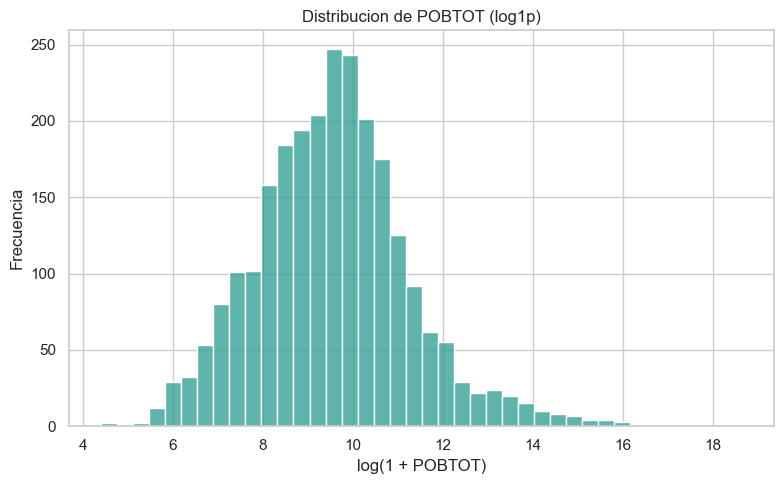

In [8]:
# Distribucion de poblacion municipal (escala log)
plt.figure(figsize=(8, 5))
if 'POBTOT' in mun.columns:
    sns.histplot(np.log1p(mun['POBTOT']), bins=40, color='#2a9d8f')
    plt.title('Distribucion de POBTOT (log1p)')
    plt.xlabel('log(1 + POBTOT)')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()


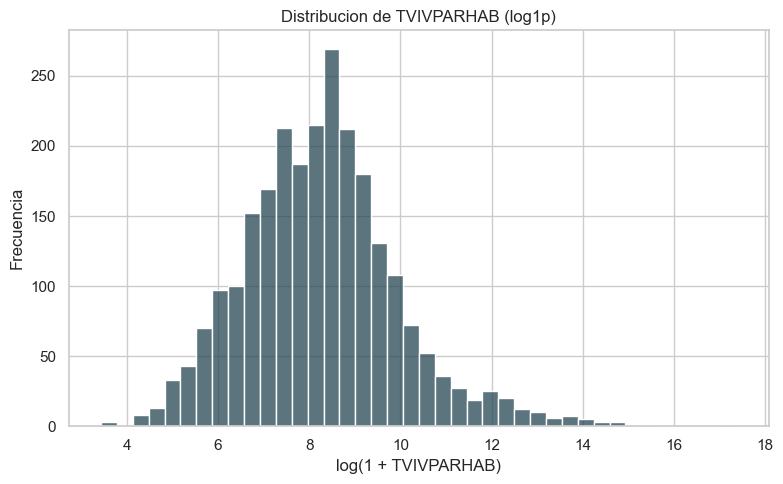

In [9]:
# Viviendas particulares habitadas (si existe)
if 'TVIVPARHAB' in mun.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(np.log1p(mun['TVIVPARHAB']), bins=40, color='#264653')
    plt.title('Distribucion de TVIVPARHAB (log1p)')
    plt.xlabel('log(1 + TVIVPARHAB)')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()


In [10]:
# Faltantes por columna (top 20)
missing_col = mun.isna().mean().sort_values(ascending=False)
missing_col.head(20)


LONGITUD      1.0
LATITUD       1.0
ALTITUD       1.0
ENTIDAD       0.0
P15SEC_COF    0.0
GRAPROES_F    0.0
GRAPROES      0.0
P18YM_PB_M    0.0
P18YM_PB_F    0.0
P18YM_PB      0.0
P15SEC_COM    0.0
P15SEC_INM    0.0
P15SEC_CO     0.0
PEA           0.0
P15SEC_INF    0.0
P15SEC_IN     0.0
P15PRI_COM    0.0
P15PRI_COF    0.0
P15PRI_CO     0.0
GRAPROES_M    0.0
dtype: float64

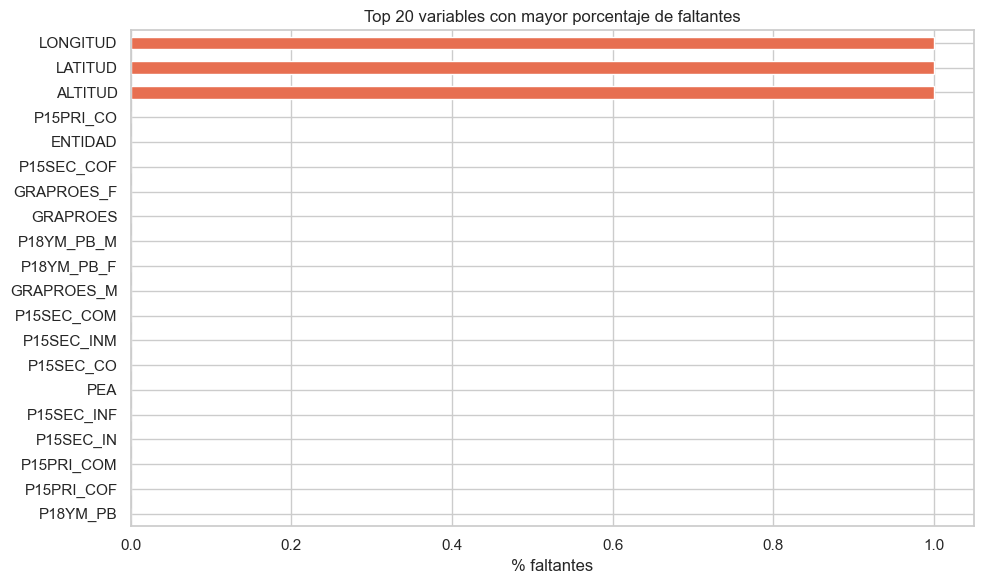

In [11]:
plt.figure(figsize=(10, 6))
missing_col.head(20).sort_values().plot(kind='barh', color='#e76f51')
plt.title('Top 20 variables con mayor porcentaje de faltantes')
plt.xlabel('% faltantes')
plt.tight_layout()
plt.show()


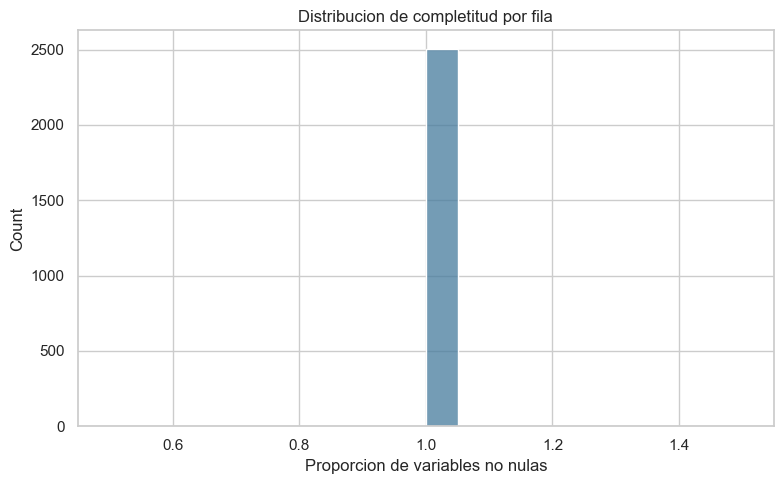

In [12]:
# Completitud por fila
row_complete = mun.drop(columns=id_cols).notna().mean(axis=1)
plt.figure(figsize=(8, 5))
sns.histplot(row_complete, bins=20, color='#457b9d')
plt.title('Distribucion de completitud por fila')
plt.xlabel('Proporcion de variables no nulas')
plt.tight_layout()
plt.show()


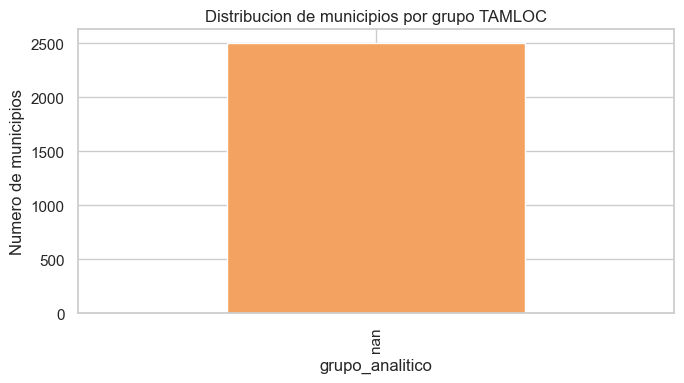

In [13]:
# Estratos por TAMLOC (integrando catalogo)

# Clasificacion simplificada del catalogo TAMLOC

def grupo_tam_loc(code):
    if pd.isna(code):
        return np.nan
    if code <= 4:
        return 'Rural (1 a 2,499 hab)'
    if code <= 8:
        return 'Transicion (2,500 a 29,999 hab)'
    return 'Urbano (30,000+ hab)'

if 'tam_loc' in tam_loc.columns:
    tam_loc = tam_loc.copy()
    tam_loc['tam_loc'] = pd.to_numeric(tam_loc['tam_loc'], errors='coerce').astype('Int64')
    mun['TAMLOC'] = pd.to_numeric(mun['TAMLOC'], errors='coerce').astype('Int64')
    tam_loc['grupo_analitico'] = tam_loc['tam_loc'].apply(grupo_tam_loc)

    mun = mun.merge(
        tam_loc[['tam_loc', 'grupo_analitico']].rename(columns={'tam_loc': 'TAMLOC'}),
        on='TAMLOC',
        how='left'
    )

    plt.figure(figsize=(7, 4))
    mun['grupo_analitico'].value_counts(dropna=False).plot(kind='bar', color='#f4a261')
    plt.title('Distribucion de municipios por grupo TAMLOC')
    plt.ylabel('Numero de municipios')
    plt.tight_layout()
    plt.show()


### Hallazgos clave del EDA

- La distribucion de poblacion municipal es altamente asimetrica, por eso se analiza en escala log.
- Hay heterogeneidad relevante en variables de vivienda y servicios basicos.
- Se observa variacion en completitud; se priorizan variables con alta cobertura para el modelado.
- La estratificacion por TAMLOC ayuda a contextualizar diferencias urbano-rural.


## 4. Completitud de la data (estilo RGM)

Calculamos completitud por columna y por fila para decidir umbrales de filtrado.


In [14]:
def resumen_completitud(df, id_cols):
    base = df.drop(columns=[c for c in id_cols if c in df.columns])
    comp = base.notna().mean().sort_values(ascending=False)
    return pd.DataFrame({
        'completitud': comp,
        'faltantes_pct': 1 - comp
    })

resumen_col = resumen_completitud(mun, id_cols)
resumen_col.head(15)


,completitud,faltantes_pct
POBTOT,1.0,0.0
P18YM_PB_F,1.0,0.0
PEA_F,1.0,0.0
PEA,1.0,0.0
GRAPROES_M,1.0,0.0
GRAPROES_F,1.0,0.0
GRAPROES,1.0,0.0
P18YM_PB_M,1.0,0.0
P18YM_PB,1.0,0.0
P15PRI_COF,1.0,0.0


In [15]:
mun

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,P_15YMAS_F,P_15YMAS_M,P_18YMAS,P_18YMAS_F,P_18YMAS_M,P_3A5,P_3A5_F,P_3A5_M,P_6A11,P_6A11_F,P_6A11_M,P_8A14,P_8A14_F,P_8A14_M,P_12A14,P_12A14_F,P_12A14_M,P_15A17,P_15A17_F,P_15A17_M,P_18A24,P_18A24_F,P_18A24_M,P_15A49_F,P_60YMAS,P_60YMAS_F,P_60YMAS_M,REL_H_M,POB0_14,POB15_64,POB65_MAS,P_0A4,P_0A4_F,P_0A4_M,P_5A9,P_5A9_F,P_5A9_M,P_10A14,P_10A14_F,P_10A14_M,P_15A19,P_15A19_F,P_15A19_M,P_20A24,P_20A24_F,P_20A24_M,P_25A29,P_25A29_F,P_25A29_M,P_30A34,P_30A34_F,P_30A34_M,P_35A39,P_35A39_F,P_35A39_M,P_40A44,P_40A44_F,P_40A44_M,P_45A49,P_45A49_F,P_45A49_M,P_50A54,P_50A54_F,P_50A54_M,P_55A59,P_55A59_F,P_55A59_M,P_60A64,P_60A64_F,P_60A64_M,P_65A69,P_65A69_F,P_65A69_M,P_70A74,P_70A74_F,P_70A74_M,P_75A79,P_75A79_F,P_75A79_M,P_80A84,P_80A84_F,P_80A84_M,P_85YMAS,P_85YMAS_F,P_85YMAS_M,PROM_HNV,PNACENT,PNACENT_F,PNACENT_M,PNACOE,PNACOE_F,PNACOE_M,PRES2015,PRES2015_F,PRES2015_M,PRESOE15,PRESOE15_F,PRESOE15_M,P3YM_HLI,P3YM_HLI_F,...,P12A14NOAF,P12A14NOAM,P15A17A,P15A17A_F,P15A17A_M,P18A24A,P18A24A_F,P18A24A_M,P8A14AN,P8A14AN_F,P8A14AN_M,P15YM_AN,P15YM_AN_F,P15YM_AN_M,P15YM_SE,P15YM_SE_F,P15YM_SE_M,P15PRI_IN,P15PRI_INF,P15PRI_INM,P15PRI_CO,P15PRI_COF,P15PRI_COM,P15SEC_IN,P15SEC_INF,P15SEC_INM,P15SEC_CO,P15SEC_COF,P15SEC_COM,P18YM_PB,P18YM_PB_F,P18YM_PB_M,GRAPROES,GRAPROES_F,GRAPROES_M,PEA,PEA_F,PEA_M,PE_INAC,PE_INAC_F,PE_INAC_M,POCUPADA,POCUPADA_F,POCUPADA_M,PDESOCUP,PDESOCUP_F,PDESOCUP_M,PSINDER,PDER_SS,PDER_IMSS,PDER_ISTE,PDER_ISTEE,PAFIL_PDOM,PDER_SEGP,PDER_IMSSB,PAFIL_IPRIV,PAFIL_OTRAI,P12YM_SOLT,P12YM_CASA,P12YM_SEPA,PCATOLICA,PRO_CRIEVA,POTRAS_REL,PSIN_RELIG,TOTHOG,HOGJEF_F,HOGJEF_M,POBHOG,PHOGJEF_F,PHOGJEF_M,VIVTOT,TVIVHAB,TVIVPAR,VIVPAR_HAB,VIVPARH_CV,TVIVPARHAB,VIVPAR_DES,VIVPAR_UT,OCUPVIVPAR,PROM_OCUP,PRO_OCUP_C,VPH_PISODT,VPH_PISOTI,VPH_1DOR,VPH_2YMASD,VPH_1CUART,VPH_2CUART,VPH_3YMASC,VPH_C_ELEC,VPH_S_ELEC,VPH_AGUADV,VPH_AEASP,VPH_AGUAFV,VPH_TINACO,VPH_CISTER,VPH_EXCSA,VPH_LETR,VPH_DRENAJ,VPH_NODREN,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC,grupo_analitico
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,64540634.0,61473390.0,5764054.0,2848875.0,2915179.0,119976584.0,61554567.0,58422017.0,115693273.0,59433559.0,56259714.0,100528155.0,51962264.0,48565891.0,93985354.0,48732991.0,45252363.0,87492680.0,45530857.0,41961823.0,6462212.0,3193548.0,3268664.0,12986217.0,6398755.0,6587462.0,15287375.0,7531118.0,7756257.0,6542801.0,3229273.0,3313528.0,6492674.0,3202134.0,3290540.0,14736111.0,7398617.0,7337494.0,33885546.0,15142976.0,8139094.0,7003882.0,95.25,31755284.0,83663440.0,10321914.0,10047365.0,4969883.0,5077482.0,10764379.0,5311288.0,5453091.0,10943540.0,5389280.0,5554260.0,10806690.0,5344540.0,5462150.0,10422095.0,5256211.0,5165884.0,9993001.0,5131597.0,4861404.0,9420827.0,4893101.0,4527726.0,9020276.0,4688746.0,4331530.0,8503586.0,4441282.0,4062304.0,7942413.0,4130069.0,3812344.0,7037532.0,3705369.0,3332163.0,5695958.0,3002982.0,2692976.0,4821062.0,2563200.0,2257862.0,3645077.0,1938227.0,1706850.0,2647340.0,1413848.0,1233492.0,1814582.0,966684.0,847898.0,1175364.0,651552.0,523812.0,1039551.0,605583.0,433968.0,2.09,102724322.0,52519974.0,50204348.0,21611963.0,11222300.0,10389663.0,111075594.0,57288776.0,53786818.0,3807844.0,1889986.0,1917858.0,7364645.0,3783447.0,...,283195.0,335038.0,4726359.0,2390407.0,2335952.0,4894125.0,2482980.0,2411145.0,412725.0,178152.0,234573.0,4456431.0,2677192.0,1779239.0,4841952.0,2791237.0,2050715.0,7731820.0,4042527.0,3689293.0,12325433.0,6515268.0,5810165.0,2913915.0,1297269.0,1616646.0,22833912.0,11857736.0,10976176.0,39977750.0,20408275.0,19569475.0,9.74,9.64,9.84,62281634.0,254

In [16]:
# Completitud promedio por entidad
comp_entidad = (
    mun.groupby('NOM_ENT')
    .apply(lambda x: x.drop(columns=[c for c in id_cols if c in x.columns], errors='ignore').notna().mean().mean())
    .sort_values(ascending=False)
)
comp_entidad.head(10)


NOM_ENT
Aguascalientes                     0.99639
Nayarit                            0.99639
Yucatán                            0.99639
Veracruz de Ignacio de la Llave    0.99639
Total nacional                     0.99639
Tlaxcala                           0.99639
Tamaulipas                         0.99639
Tabasco                            0.99639
Sonora                             0.99639
Sinaloa                            0.99639
dtype: float64

## 5. Seleccion de variables por correlacion y variabilidad (estilo RGM)

Procedimiento:

- Se eliminan columnas con baja completitud.
- Se calcula un score combinado de variabilidad (std, IQR, CV).
- Se filtran variables con correlacion alta para reducir redundancia (|r| > 0.90).


In [17]:
# Matriz base para seleccion data-driven
X = mun.drop(columns=[c for c in id_cols if c in mun.columns], errors='ignore')
X = X.select_dtypes(include='number')

# Umbral de completitud por columna
min_col_complete = 0.95
col_complete = X.notna().mean()
cols_keep = col_complete[col_complete >= min_col_complete].index

X = X[cols_keep]
X_clean = X.dropna()

print(f'Variables numericas con >= {min_col_complete:.0%} completitud: {X.shape[1]}')
print(f'Filas usadas para correlaciones: {X_clean.shape[0]}')


Variables numericas con >= 95% completitud: 276
Filas usadas para correlaciones: 2502


In [18]:
# Score de variabilidad
std = X_clean.std()
iqr = X_clean.quantile(0.75) - X_clean.quantile(0.25)
cv = std / (X_clean.mean().abs() + 1e-9)

score = pd.concat([std, iqr, cv], axis=1)
score.columns = ['std', 'iqr', 'cv']

score_rank = score.rank(pct=True).mean(axis=1)
score_rank = score_rank.sort_values(ascending=False)

score_rank.head(15)


PSINDER       0.844203
PCATOLICA     0.841787
P_18YMAS      0.827295
P18YM_PB      0.823671
PEA           0.822464
P_15YMAS      0.822464
PDER_IMSS     0.818841
POB15_64      0.817633
POCUPADA      0.814010
P_12YMAS      0.812802
PRES2015      0.807971
P_18YMAS_F    0.792271
P_15YMAS_F    0.792271
PRES2015_F    0.788647
P_12YMAS_F    0.787440
dtype: float64

In [19]:
# Filtro de correlacion para evitar redundancia
corr = X_clean.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

selected = []
for var in score_rank.index:
    if not selected:
        selected.append(var)
        continue
    if (corr.loc[var, selected] <= 0.90).all():
        selected.append(var)

# Top N variables por score y baja colinealidad
top_n = 30
top_vars = selected[:top_n]

print(f"Variables candidatas (top {top_n}):")
print(top_vars)

ranking_final = score_rank.loc[top_vars]
X_sel = X_clean[top_vars].copy()

ranking_final


Variables candidatas (top 30):
['PSINDER', 'P3HLINHE', 'GRAPROES_F', 'REL_H_M', 'PRO_OCUP_C', 'PROM_HNV', 'PROM_OCUP']


PSINDER       0.844203
P3HLINHE      0.392512
GRAPROES_F    0.021739
REL_H_M       0.018116
PRO_OCUP_C    0.010870
PROM_HNV      0.009662
PROM_OCUP     0.008454
dtype: float64

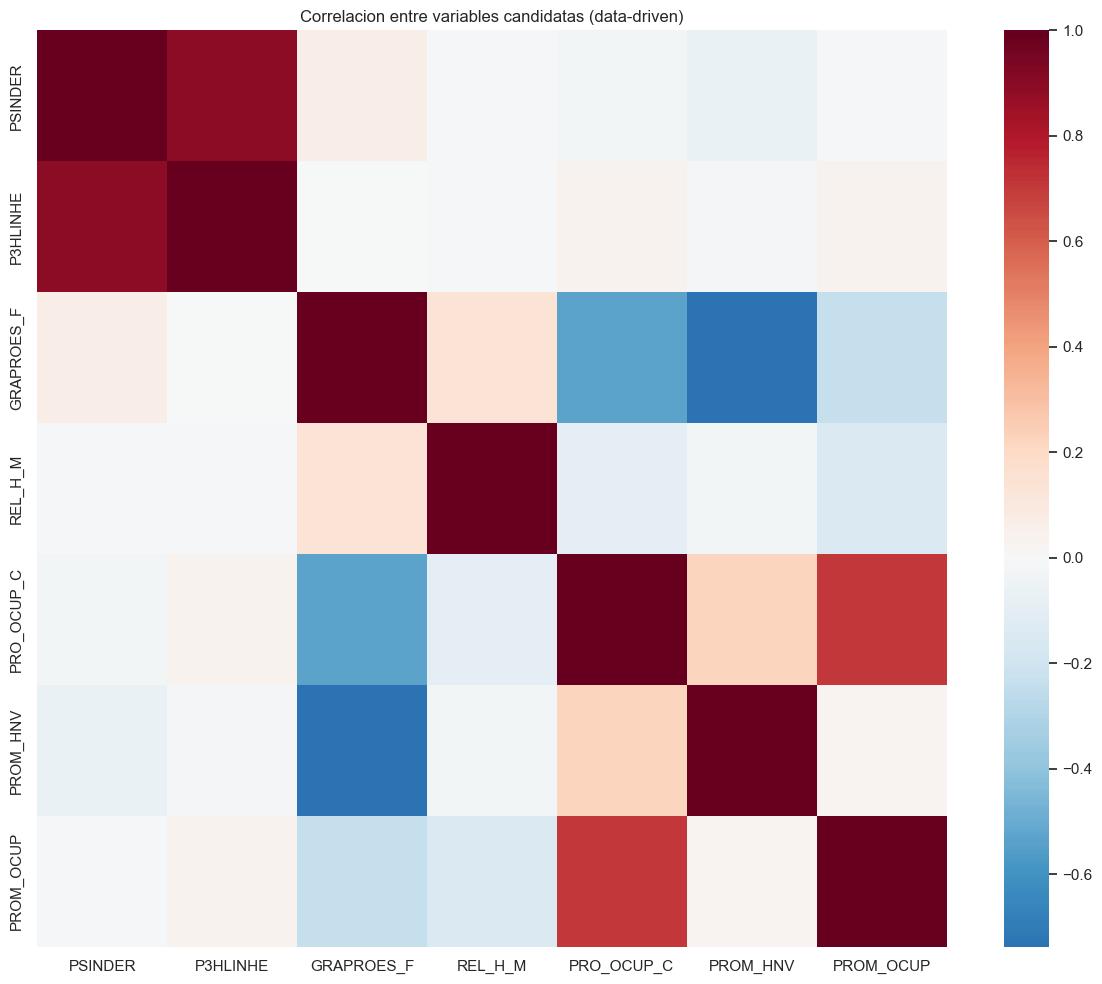

In [20]:
# Matriz de correlacion para variables candidatas
plt.figure(figsize=(12, 10))
sns.heatmap(X_sel.corr(), cmap='RdBu_r', center=0, cbar=True)
plt.title('Correlacion entre variables candidatas (data-driven)')
plt.tight_layout()
plt.show()


### Hallazgos clave del Punto 5

- El score de variabilidad identifica variables con alta capacidad de discriminar municipios.
- El filtro de correlacion reduce duplicidad informativa.
- El set final es una base empirica robusta para cruzar con variables de marginacion.


## 6. Seleccion de variables por definicion de marginacion (estilo DMC)

Se construyen proporciones comparables a partir de numeradores y denominadores oficiales del censo.


In [21]:
import re

# Catalogo del diccionario para trazabilidad
mask = dic_raw[0].astype(str).str.fullmatch(r'\d+', na=False) & dic_raw[3].notna()
catalogo = dic_raw.loc[mask, [1, 2, 3]].copy()
catalogo.columns = ['Indicador', 'Descripcion', 'Mnemónico']
catalogo['Mnemónico'] = catalogo['Mnemónico'].astype(str).str.strip()
catalogo = catalogo.drop_duplicates(subset='Mnemónico').reset_index(drop=True)

vars_geo = {
    'ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN',
    'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC'
}

vars_base_ahora = {
    'P15YM_AN', 'P15YM_SE', 'P6A11_NOA', 'P12A14NOA',
    'PSINDER', 'VPH_PISOTI', 'VPH_NODREN', 'VPH_AGUAFV', 'VPH_S_ELEC', 'VPH_SINTIC',
    'P_15YMAS', 'P_6A11', 'P_12A14', 'POBTOT', 'TVIVPARHAB'
}

age_pattern = re.compile(r'^(P_?\d+A\d+|P_?\d+YMAS|P\d+A\d+|POB\d+_\d+)$')


def dominio_catalogo(row):
    var = row['Mnemónico']
    txt = f"{row['Indicador']} {row['Descripcion']}".lower()

    if var in vars_geo:
        return 'Geografia e identificacion'

    if 'viviendas particulares habitadas' in txt or var.startswith('VPH_'):
        if any(k in txt for k in ['no disponen de drenaje', 'no disponen de agua entubada', 'no disponen de energia electrica', 'piso de tierra']):
            return 'Vivienda y servicios basicos'
        if any(k in txt for k in ['tecnolog', 'internet', 'computadora', 'celular', 'television', 'radio', 'refrigerador', 'lavadora', 'automovil', 'motocicleta', 'bicicleta']):
            return 'Tecnologia y bienes del hogar'
        return 'Condiciones de vivienda'

    if any(k in txt for k in ['analfabeta', 'escolaridad', 'asiste a la escuela', 'primaria', 'secundaria']):
        return 'Educacion'

    if any(k in txt for k in ['servicios de salud', 'sin afiliacion', 'afiliada a servicios de salud']):
        return 'Salud y seguridad social'

    if any(k in txt for k in ['economicamente activa', 'ocupada', 'desocupada', 'no economicamente activa']):
        return 'Actividad economica'

    if any(k in txt for k in ['lengua indig', 'afromexicana', 'afrodescendiente']):
        return 'Poblacion indigena y afrodescendiente'

    if any(k in txt for k in ['discapacidad', 'limitacion']):
        return 'Discapacidad y limitaciones'

    if any(k in txt for k in ['residente en', 'nacida en la entidad', 'nacida en otra entidad']):
        return 'Migracion y movilidad'

    if any(k in txt for k in ['catolica', 'religion', 'estado conyugal', 'hijas e hijos nacidos vivos']):
        return 'Estructura sociodemografica'

    if var in {'POBTOT', 'POBFEM', 'POBMAS'} or age_pattern.match(var) or var.startswith('P_'):
        return 'Demografia y estructura por edad'

    if any(k in txt for k in ['hogares', 'jefatura', 'hogar']):
        return 'Hogares'

    return 'Otros'


def recomendar_uso(row):
    var = row['Mnemónico']
    dom = row['Dominio']
    is_sexo = var.endswith('_F') or var.endswith('_M')

    if var in vars_base_ahora:
        return ('Usar ahora', 'Variable base directa para construir proporciones comparables.')

    if dom == 'Geografia e identificacion':
        return ('No usar en indice', 'Llave geografica o referencia espacial; util para unir/ubicar.')

    if dom == 'Demografia y estructura por edad':
        if is_sexo:
            return ('Agregar en analisis especifico', 'Desagregacion por sexo; util si se analiza brecha de genero.')
        return ('Usar para segmentar', 'Aporta composicion poblacional, no privacion directa.')

    if dom in ['Educacion', 'Salud y seguridad social', 'Vivienda y servicios basicos']:
        if is_sexo:
            return ('Agregar en analisis especifico', 'Indicador relevante, version por sexo es complementaria.')
        return ('Agregar bloque candidato', 'Dominio estructural de marginacion; candidato natural.')

    if dom == 'Tecnologia y bienes del hogar':
        if var == 'VPH_SINTIC':
            return ('Usar ahora', 'Carencia digital directa incluida en el modelo base.')
        return ('Agregar como contexto', 'Complementa brecha digital/equipamiento.')

    if dom in ['Actividad economica', 'Discapacidad y limitaciones', 'Poblacion indigena y afrodescendiente', 'Migracion y movilidad', 'Hogares']:
        return ('Agregar como contexto', 'Explica heterogeneidad territorial; util para extensiones.')

    if dom == 'Estructura sociodemografica':
        return ('No usar en indice', 'Describe perfil social/cultural; no mide privacion material directa.')

    return ('Revisar manualmente', 'Sin clasificacion robusta automatica; requiere revision.')


catalogo['Dominio'] = catalogo.apply(dominio_catalogo, axis=1)
catalogo[['Recomendacion', 'Justificacion']] = catalogo.apply(
    lambda r: pd.Series(recomendar_uso(r)), axis=1
)

catalogo_clasificado = catalogo[[
    'Mnemónico', 'Indicador', 'Dominio', 'Recomendacion', 'Justificacion'
]].sort_values(['Recomendacion', 'Dominio', 'Mnemónico']).reset_index(drop=True)

print('Resumen por recomendacion:')
display(catalogo_clasificado.groupby('Recomendacion').size().sort_values(ascending=False))


Resumen por recomendacion:


Recomendacion
Agregar en analisis especifico    77
Revisar manualmente               70
Agregar como contexto             50
Usar para segmentar               32
Agregar bloque candidato          30
Usar ahora                        15
No usar en indice                 12
dtype: int64

In [22]:
# Variables artificiales de marginacion (tasas)

def agregar_tasa(df, numerador, denominador, nombre, sentido='directo'):
    tasa = 100 * df[numerador] / df[denominador]
    if sentido == 'inverso':
        tasa = 100 - tasa
    df[nombre] = tasa

# Nucleo + ampliacion (set DMC)
especificaciones = [
    # Nucleo
    ('pct_analfabetismo_15ymas', 'P15YM_AN', 'P_15YMAS', 'directo', 'Usar ahora'),
    ('pct_sin_escolaridad_15ymas', 'P15YM_SE', 'P_15YMAS', 'directo', 'Usar ahora'),
    ('pct_no_asiste_6a11', 'P6A11_NOA', 'P_6A11', 'directo', 'Usar ahora'),
    ('pct_no_asiste_12a14', 'P12A14NOA', 'P_12A14', 'directo', 'Usar ahora'),
    ('pct_sin_derechohab', 'PSINDER', 'POBTOT', 'directo', 'Usar ahora'),
    ('pct_piso_tierra', 'VPH_PISOTI', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_drenaje', 'VPH_NODREN', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_agua_entubada', 'VPH_AGUAFV', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_electricidad', 'VPH_S_ELEC', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_tic', 'VPH_SINTIC', 'TVIVPARHAB', 'directo', 'Usar ahora'),

    # Ampliacion desde catalogo
    ('pct_no_asiste_3a5', 'P3A5_NOA', 'P_3A5', 'directo', 'Agregar bloque candidato'),
    ('pct_no_asiste_15a17', 'P15A17A', 'P_15A17', 'inverso', 'Agregar bloque candidato'),
    ('pct_no_asiste_18a24', 'P18A24A', 'P_18A24', 'inverso', 'Agregar bloque candidato'),
    ('pct_primaria_incompleta_15ymas', 'P15PRI_IN', 'P_15YMAS', 'directo', 'Agregar bloque candidato'),
    ('pct_secundaria_incompleta_15ymas', 'P15SEC_IN', 'P_15YMAS', 'directo', 'Agregar bloque candidato'),
    ('pct_sin_posbasica_18ymas', 'P18YM_PB', 'P_18YMAS', 'inverso', 'Agregar bloque candidato'),
    ('pct_viv_sin_agua_drenaje_elec', 'VPH_NDEAED', 'TVIVPARHAB', 'directo', 'Agregar bloque candidato'),
]

analisis_mun = mun.copy()

for nombre, num, den, sentido, _ in especificaciones:
    agregar_tasa(analisis_mun, num, den, nombre, sentido=sentido)

vars_marginacion = [x[0] for x in especificaciones]

ficha_variables = pd.DataFrame(especificaciones, columns=[
    'Variable_artificial', 'Numerador', 'Denominador', 'Sentido', 'Origen_catalogo'
])

reco = catalogo_clasificado.set_index('Mnemónico')['Recomendacion'].to_dict()
ficha_variables['Recomendacion_numerador_catalogo'] = ficha_variables['Numerador'].map(reco)

print('Ficha tecnica de variables usadas en el modelo:')
display(ficha_variables)

modelo_df = (
    analisis_mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN'] + vars_marginacion]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f'Municipios con informacion completa para modelado: {modelo_df.shape[0]:,}')


Ficha tecnica de variables usadas en el modelo:


,Variable_artificial,Numerador,Denominador,Sentido,Origen_catalogo,Recomendacion_numerador_catalogo
0,pct_analfabetismo_15ymas,P15YM_AN,P_15YMAS,directo,Usar ahora,Usar ahora
1,pct_sin_escolaridad_15ymas,P15YM_SE,P_15YMAS,directo,Usar ahora,Usar ahora
2,pct_no_asiste_6a11,P6A11_NOA,P_6A11,directo,Usar ahora,Usar ahora
3,pct_no_asiste_12a14,P12A14NOA,P_12A14,directo,Usar ahora,Usar ahora
4,pct_sin_derechohab,PSINDER,POBTOT,directo,Usar ahora,Usar ahora
5,pct_piso_tierra,VPH_PISOTI,TVIVPARHAB,directo,Usar ahora,Usar ahora
6,pct_sin_drenaje,VPH_NODREN,TVIVPARHAB,directo,Usar ahora,Usar ahora
7,pct_sin_agua_entubada,VPH_AGUAFV,TVIVPARHAB,directo,Usar ahora,Usar ahora
8,pct_sin_electricidad,VPH_S_ELEC,TVIVPARHAB,directo,Usar ahora,Usar ahora
9,pct_sin_tic,VPH_SINTIC,TVIVPARHAB,directo,Usar ahora,Usar ahora


Municipios con informacion completa para modelado: 2,502


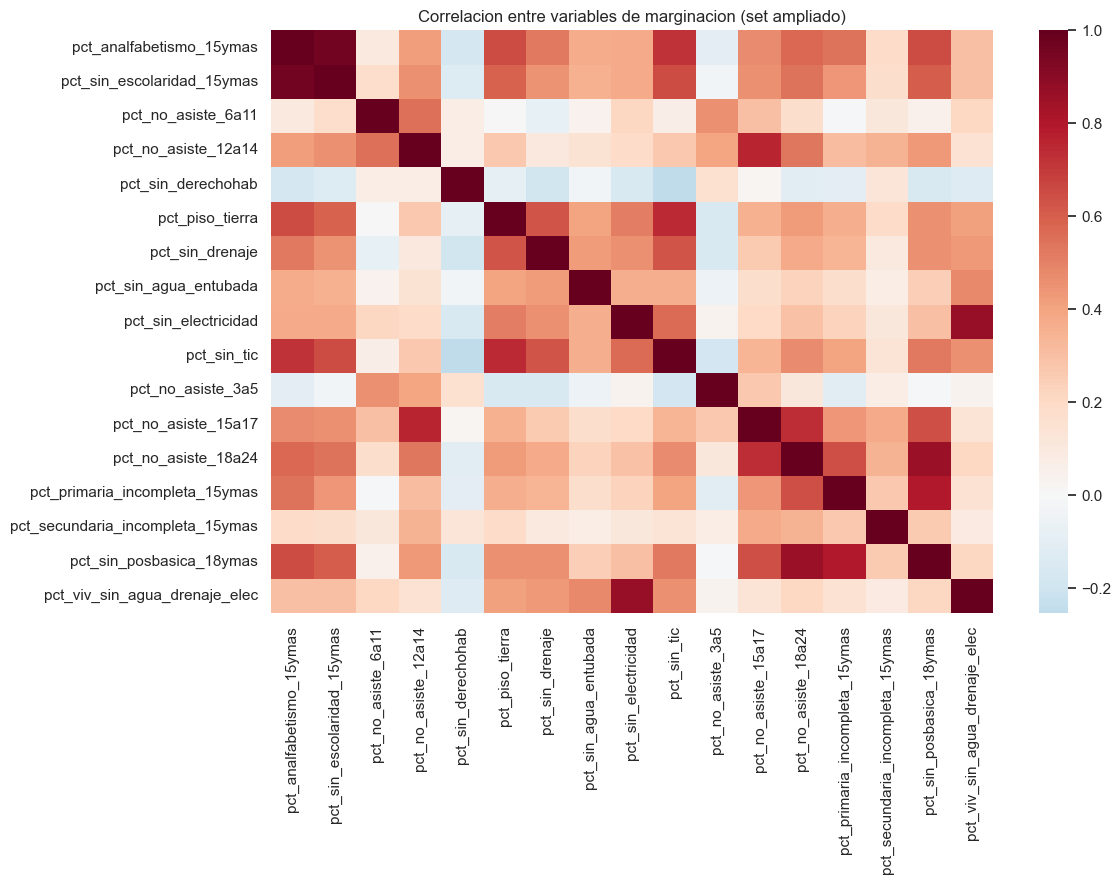

In [23]:
# Correlacion entre variables de marginacion
plt.figure(figsize=(12, 9))
corr_margin = modelo_df[vars_marginacion].corr()
sns.heatmap(corr_margin, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlacion entre variables de marginacion (set ampliado)')
plt.tight_layout()
plt.show()


### Hallazgos clave del Punto 6

- Las variables seleccionadas cubren dimensiones educativas, salud y vivienda.
- Las tasas permiten comparabilidad entre municipios de distinto tamano.
- La matriz de correlacion muestra coherencia conceptual y redundancias controlables.


## 7. Cruce de variables (definicion + correlacion)

Se integra la logica conceptual de marginacion con la evidencia estadistica:

- Variables con numeradores/denominadores presentes en el top de variabilidad.
- Variables con alta correlacion con el set data-driven.
- Variables con buena completitud y variabilidad dentro del set de marginacion.


In [24]:
spec_df = ficha_variables.copy()

# Bandera de presencia en top_vars
spec_df['num_in_top'] = spec_df['Numerador'].isin(top_vars)
spec_df['den_in_top'] = spec_df['Denominador'].isin(top_vars)

# Completitud y variabilidad en variables de marginacion
comp_var = modelo_df[vars_marginacion].notna().mean()
std_m = modelo_df[vars_marginacion].std()
iqr_m = modelo_df[vars_marginacion].quantile(0.75) - modelo_df[vars_marginacion].quantile(0.25)
cv_m = std_m / (modelo_df[vars_marginacion].mean().abs() + 1e-9)

score_m = pd.concat([std_m, iqr_m, cv_m], axis=1)
score_m.columns = ['std', 'iqr', 'cv']
score_m_rank = score_m.rank(pct=True).mean(axis=1)

spec_df['completitud'] = spec_df['Variable_artificial'].map(comp_var)
spec_df['score_variabilidad'] = spec_df['Variable_artificial'].map(score_m_rank)

# Correlacion cruzada entre variables de marginacion y top_vars
X_sel_aligned = mun.loc[modelo_df.index, top_vars].copy()
X_sel_aligned = X_sel_aligned.apply(pd.to_numeric, errors='coerce')

corr_cross = {}
for col in X_sel_aligned.columns:
    corr_cross[col] = modelo_df[vars_marginacion].corrwith(X_sel_aligned[col])

corr_cross = pd.DataFrame(corr_cross)
max_corr = corr_cross.abs().max(axis=1)

spec_df['max_corr_top'] = spec_df['Variable_artificial'].map(max_corr)

# Score de cruce: mezcla completitud, variabilidad y evidencia data-driven
spec_df['score_cruce'] = (
    0.40 * spec_df['completitud'] +
    0.30 * spec_df['score_variabilidad'] +
    0.30 * spec_df['max_corr_top'].fillna(0)
)

spec_df = spec_df.sort_values('score_cruce', ascending=False)

# Variables core + top score_cruce
vars_core = [x[0] for x in especificaciones if x[4] == 'Usar ahora']

vars_data = spec_df['Variable_artificial'].head(12).tolist()
vars_final = list(dict.fromkeys(vars_core + vars_data))

print('Variables finales (cruce definicion + datos):')
print(vars_final)

spec_df.head(12)


Variables finales (cruce definicion + datos):
['pct_analfabetismo_15ymas', 'pct_sin_escolaridad_15ymas', 'pct_no_asiste_6a11', 'pct_no_asiste_12a14', 'pct_sin_derechohab', 'pct_piso_tierra', 'pct_sin_drenaje', 'pct_sin_agua_entubada', 'pct_sin_electricidad', 'pct_sin_tic', 'pct_sin_posbasica_18ymas', 'pct_no_asiste_18a24', 'pct_no_asiste_15a17', 'pct_primaria_incompleta_15ymas', 'pct_no_asiste_3a5']


,Variable_artificial,Numerador,Denominador,Sentido,Origen_catalogo,Recomendacion_numerador_catalogo,num_in_top,den_in_top,completitud,score_variabilidad,max_corr_top,score_cruce
15,pct_sin_posbasica_18ymas,P18YM_PB,P_18YMAS,inverso,Agregar bloque candidato,Agregar bloque candidato,False,False,1.0,0.647059,0.927003,0.872219
0,pct_analfabetismo_15ymas,P15YM_AN,P_15YMAS,directo,Usar ahora,Usar ahora,False,False,1.0,0.588235,0.852410,0.832194
6,pct_sin_drenaje,VPH_NODREN,TVIVPARHAB,directo,Usar ahora,Usar ahora,False,False,1.0,0.843137,0.513026,0.806849
12,pct_no_asiste_18a24,P18A24A,P_18A24,inverso,Agregar bloque candidato,Agregar bloque candidato,False,False,1.0,0.529412,0.793522,0.796880
11,pct_no_asiste_15a17,P15A17A,P_15A17,inverso,Agregar bloque candidato,Agregar bloque candidato,False,False,1.0,0.705882,0.599187,0.791521
1,pct_sin_escolaridad_15ymas,P15YM_SE,P_15YMAS,directo,Usar ahora,Usar ahora,False,False,1.0,0.490196,0.809486,0.789904
9,pct_sin_tic,VPH_SINTIC,TVIVPARHAB,directo,Usar ahora,Usar ahora,False,False,1.0,0.568627,0.657822,0.767935
5,pct_piso_tierra,VPH_PISOTI,TVIVPARHAB,directo,Usar ahora,Usar ahora,False,False,1.0,0.627451,0.590495,0.765384
13,pct_primaria_incompleta_15ymas,P15PRI_IN,P_15YMAS,directo,Agregar bloque candidato,Agregar bloque candidato,False,False,1.0,0.392157,0.801458,0.758084
7,pct_sin_agua_entubada,VPH_AGUAFV,TVIVPARHAB,directo,Usar ahora,Usar ahora,False,False,1.0,0.607843,0.319577,0.678226


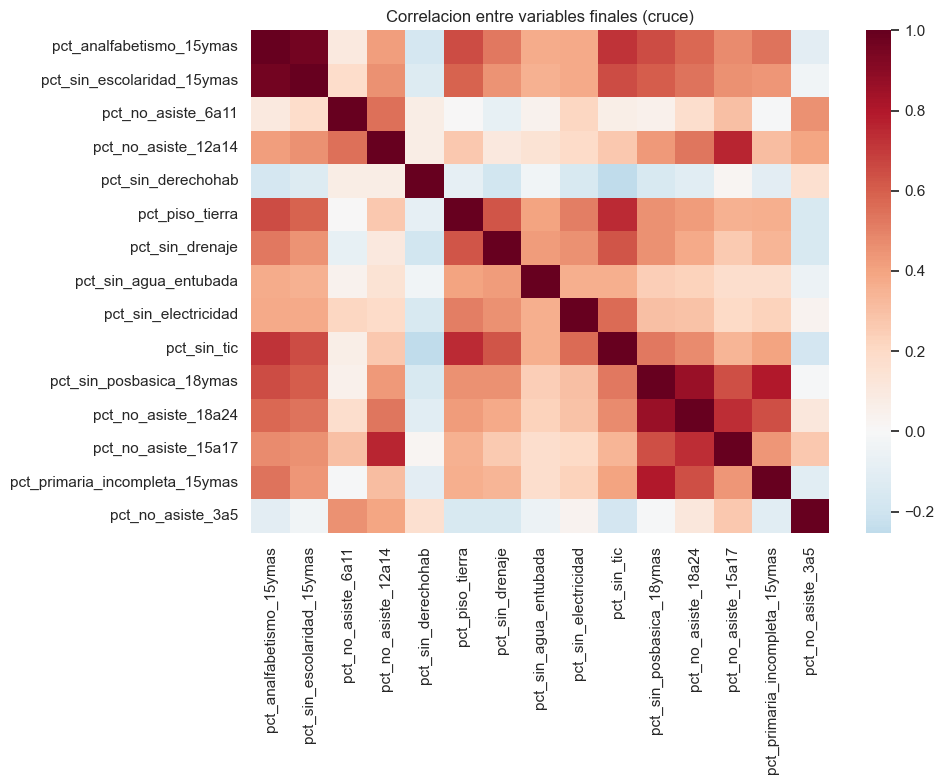

In [25]:
# Correlacion del set final
plt.figure(figsize=(10, 8))
sns.heatmap(modelo_df[vars_final].corr(), cmap='RdBu_r', center=0)
plt.title('Correlacion entre variables finales (cruce)')
plt.tight_layout()
plt.show()


### Hallazgos clave del Punto 7

- El cruce garantiza coherencia conceptual y respaldo empirico.
- Las variables finales son comparables, con buena cobertura y baja redundancia.


## 8. PCA a 2 dimensiones (variables finales)

Se realiza PCA con estandarizacion previa. Se reporta varianza explicada y cargas para interpretar la contribucion de cada variable.


In [26]:
X_final = modelo_df[vars_final].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = modelo_df[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN']].copy()
pca_df['PC1'] = X_pca[:, 0]
pca_df['PC2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada PC1: {var_exp[0]:.4f}')
print(f'Varianza explicada PC2: {var_exp[1]:.4f}')
print(f'Varianza acumulada (2 componentes): {var_exp.sum():.4f}')


Varianza explicada PC1: 0.4160
Varianza explicada PC2: 0.1554
Varianza acumulada (2 componentes): 0.5715


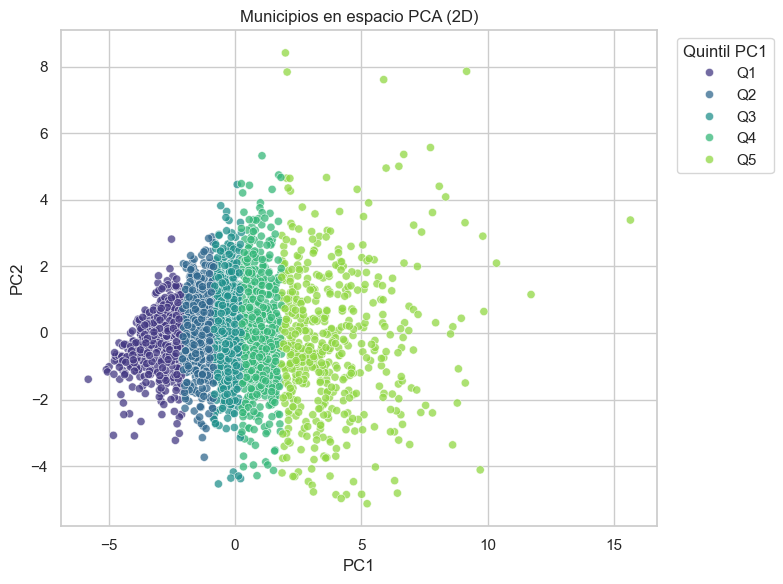

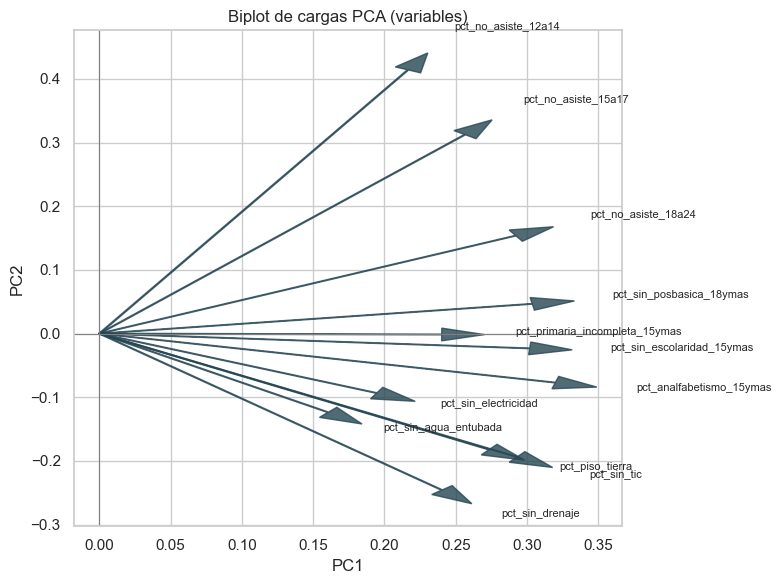

In [37]:
# Proyeccion en el espacio PCA 2D
pca_df['quintil_pc1'] = pd.qcut(pca_df['PC1'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='quintil_pc1',
    palette='viridis',
    alpha=0.75,
    s=35
)
plt.title('Municipios en espacio PCA (2D)')
plt.legend(title='Quintil PC1', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Biplot: cargas de variables en PCA
loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_final,
    columns=['PC1', 'PC2']
)

plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(0, color='gray', lw=0.8)

# Mostrar solo variables con mayor carga en PC1
vars_biplot = loadings['PC1'].abs().sort_values(ascending=False).head(12).index
for var in vars_biplot:
    x = loadings.loc[var, 'PC1']
    y = loadings.loc[var, 'PC2']
    plt.arrow(0, 0, x, y, color='#264653', alpha=0.8, head_width=0.02, length_includes_head=True)
    plt.text(x * 1.08, y * 1.08, var, fontsize=8)

plt.title('Biplot de cargas PCA (variables)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


In [28]:
# Cargas del PCA (biplot simplificado)
loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_final,
    columns=['PC1', 'PC2']
)

print('Cargas PCA (ordenadas por contribucion absoluta en PC1):')
display(loadings.sort_values('PC1', key=np.abs, ascending=False).round(3).head(12))


Cargas PCA (ordenadas por contribucion absoluta en PC1):


,PC1,PC2
pct_analfabetismo_15ymas,0.349,-0.084
pct_sin_posbasica_18ymas,0.333,0.051
pct_sin_escolaridad_15ymas,0.332,-0.026
pct_no_asiste_18a24,0.319,0.168
pct_sin_tic,0.318,-0.210
pct_piso_tierra,0.298,-0.199
pct_no_asiste_15a17,0.275,0.336
pct_primaria_incompleta_15ymas,0.270,-0.002
pct_sin_drenaje,0.261,-0.267
pct_no_asiste_12a14,0.230,0.441


### Hallazgos clave del Punto 8

- PC1 captura la mayor parte de la varianza de marginacion.
- Las cargas permiten interpretar que PC1 resume carencias estructurales.


## 9. Indice de marginacion municipal (inspirado en indice de criminalidad)

Se usa PC1 como indice y se reescala a [0, 1] con MinMaxScaler, siguiendo la idea del indice de criminalidad.


In [35]:
# Orientamos PC1 para que mayor valor signifique mayor marginacion
prom_carencias = X_final.mean(axis=1)

corr_pc1 = np.corrcoef(pca_df['PC1'], prom_carencias)[0, 1]

pc1_oriented = pca_df['PC1'] if corr_pc1 >= 0 else -pca_df['PC1']

indice_df = pca_df[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN']].copy()
indice_df['indice_marginacion_raw'] = pc1_oriented

scaler_mm = MinMaxScaler(feature_range=(0, 100))
indice_df['indice_marginacion'] = scaler_mm.fit_transform(indice_df[['indice_marginacion_raw']])
indice_df['quintil_indice'] = pd.qcut(indice_df['indice_marginacion'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
print('Top 10 municipios con mayor marginaci?n (?ndice 0-100):')
display(indice_df.sort_values('indice_marginacion', ascending=False).head(10))
print('Top 10 municipios con menor marginaci?n (?ndice 0-100):')
display(indice_df.sort_values('indice_marginacion', ascending=True).head(10))


Top 10 municipios con mayor marginaci?n (?ndice 0-100):


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,indice_marginacion_raw,indice_marginacion,quintil_indice
222,8,Chihuahua,8,Batopilas de Manuel Gómez Morín,15.653959,100.000000,Q5
464,12,Guerrero,78,Cochoapa el Grande,11.722510,81.677715,Q5
111,7,Chiapas,22,Chalchihuitán,10.354527,75.302314,Q5
1045,20,Oaxaca,16,Coicoyán de las Flores,9.855802,72.978037,Q5
171,7,Chiapas,82,Sitalá,9.814390,72.785036,Q5
313,10,Durango,14,Mezquital,9.711388,72.305003,Q5
226,8,Chihuahua,12,Carichí,9.172556,69.793809,Q5
965,18,Nayarit,9,Del Nayar,9.119569,69.546867,Q5
145,7,Chiapas,56,Mitontic,9.109904,69.501821,Q5
279,8,Chihuahua,65,Urique,8.961517,68.810276,Q5


Top 10 municipios con menor marginaci?n (?ndice 0-100):


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,indice_marginacion_raw,indice_marginacion,quintil_indice
295,9,Ciudad de México,14,Benito Juárez,-5.803242,0.000000,Q1
297,9,Ciudad de México,16,Miguel Hidalgo,-5.085726,3.343941,Q1
1379,20,Oaxaca,350,San Sebastián Tutla,-5.040276,3.555758,Q1
284,9,Ciudad de México,3,Coyoacán,-4.976434,3.853293,Q1
1276,20,Oaxaca,247,Capulálpam de Méndez,-4.807571,4.640266,Q1
1719,21,Puebla,119,San Andrés Cholula,-4.786802,4.737057,Q1
519,13,Hidalgo,51,Mineral de la Reforma,-4.767929,4.825017,Q1
2095,29,Tlaxcala,33,Tlaxcala,-4.759292,4.865270,Q1
733,15,México,54,Metepec,-4.723808,5.030638,Q1
699,15,México,20,Coacalco de Berriozábal,-4.683604,5.218005,Q1


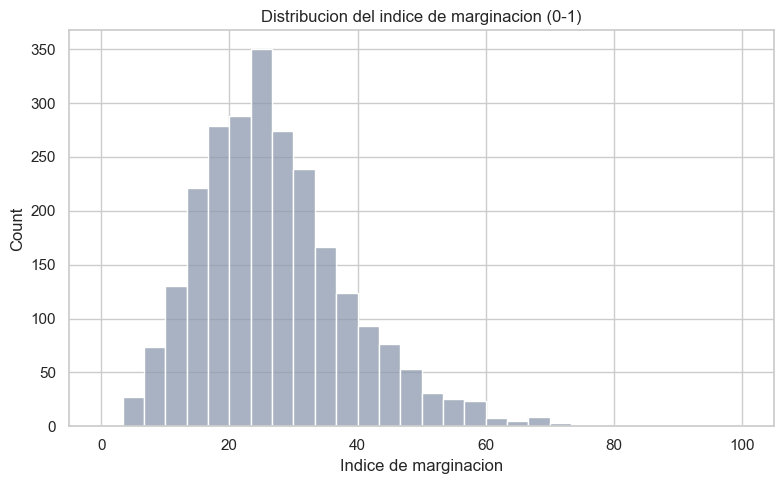

In [36]:
# Distribucion del indice
plt.figure(figsize=(8, 5))
sns.histplot(indice_df['indice_marginacion'], bins=30, color='#8d99ae')
plt.title('Distribucion del indice de marginacion (0-1)')
plt.xlabel('Indice de marginacion')
plt.tight_layout()
plt.show()


In [ ]:
# Guardado opcional del indice
out_path = 'data/indice_marginacion_municipal.csv'
indice_df.to_csv(out_path, index=False)
print(f'Archivo generado: {out_path}')


Archivo generado: data/indice_marginacion_municipal.csv


## 10. Conclusiones

- Se genero un set final de variables consistente con la definicion de marginacion y respaldado por evidencia estadistica.
- El PCA en 2D permite visualizar agrupamientos municipales en terminos de carencias.
- El indice de marginacion municipal es interpretable y comparable (escala 0-1).


## 11. Mapa de Mexico con el indice de marginacion

Requiere `geopandas`. Si no esta instalado, puede agregarse con `pip install geopandas`.


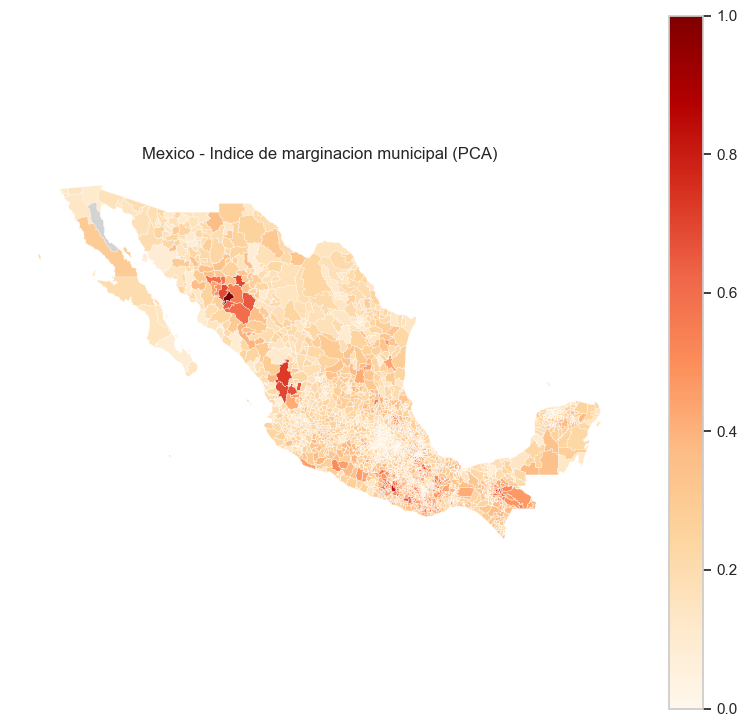

In [ ]:
# Mapa nacional (municipios) con el indice generado
try:
    import geopandas as gpd
except ImportError:
    raise ImportError('Se requiere geopandas para leer el SHP. Instala con: pip install geopandas')

shp_path = 'data/mun22gw/mun22gw.shp'
gdf = gpd.read_file(shp_path)

# Normalizamos claves de union
if 'CVE_ENT' in gdf.columns and 'CVE_MUN' in gdf.columns:
    gdf['CVE_ENT'] = gdf['CVE_ENT'].astype(str).str.zfill(2)
    gdf['CVE_MUN'] = gdf['CVE_MUN'].astype(str).str.zfill(3)
else:
    print('Columnas disponibles en el SHP:', gdf.columns.tolist())
    raise KeyError('No se encontraron columnas CVE_ENT y CVE_MUN en el SHP.')

indice_df['CVE_ENT'] = indice_df['ENTIDAD'].astype(int).astype(str).str.zfill(2)
indice_df['CVE_MUN'] = indice_df['MUN'].astype(int).astype(str).str.zfill(3)

# Merge nacional
mex = gdf.merge(
    indice_df[['CVE_ENT', 'CVE_MUN', 'indice_marginacion']],
    on=['CVE_ENT', 'CVE_MUN'],
    how='left'
)

ax = mex.plot(
    column='indice_marginacion',
    cmap='OrRd',
    legend=True,
    figsize=(10, 9),
    edgecolor='white',
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin dato'}
)
ax.set_title('Mexico - Indice de marginacion municipal (PCA)')
ax.axis('off')
plt.show()
